Nom :   Khadijetou Mohamed abe    

Filière :  GLCC

-------------------------------------------------------------TP ML------------------------------------------------------------------

# Objectif :

Ce travail présente l'implémentation "from scratch" des modèles de régression linéaire (simple, multiple et polynomiale) utilisant la descente de gradient, ainsi qu'une comparaison systématique de leurs performances avec celles de la bibliothèque sklearn.

Pour présenter ce travail de manière structurée, l'organisation choisie est la suivante :

    1. Code scratch des fonctions de régression (modèle, gradient, Algorithme de descente de gradient) qui s'adaptent automatiquement aux dimensions des données selon chaque type de régression

    2. PARTIE 1 : Régression linéaire simple
            a. Jeu de données (DATASET)
            b. Exécution du code scratch
            c. Code sklearn
            d. Comparaison et graphiques (scratch/sklearn)

    3. PARTIE 2 : Régression linéaire multiple (même structure)
    
    4. PARTIE 3 : Régression polynomiale (même structure)


# 1.CODE SCRATCH

Ces fonctions sont définies une seule fois. Grâce à l'algèbre linéaire, elles s'adaptent 
automatiquement à 1, 3 ou N variables (n_features), ainsi qu'aux transformations polynomiales.


In [50]:
import numpy as np
import matplotlib.pyplot as plt


# a. MODÈLE
def model(X, W):
    # """
    # Modèle linéaire de la forme f(x) = X.W 
    # - En simple : f(xi) = w1*xi + w0
    # - En multiple : f(xi) = w0 + w1*xi1 + w2*xi2 + w3*xi3 ... + wn*xin 
    # - En polynomial : f(xi) = w0 + w1*xi + w2*xi**2 ... + wn*xi**n (X doit déjà contenir les puissances de x)
    # Équivalent au produit matriciel X.W, retourne y_predict de taille (n_samples, 1)
    # Remarque : n_samples = nombre d’exemples (targets) dans l’échantillon
    # """
    # X.dot correspond au produit matriciel en Python
    return X.dot(W)


# b. Gradient
def calcul_gradient(X, y, W):
    # nombre de lignes de y
    n = len(y)   
    # prédiction du modèle pour calculer l'erreur par rapport aux valeurs réelles
    y_predict = model(X, W)
    # calcul de l'erreur : différence entre la prédiction et le réel (colonne par colonne)
    erreur = y_predict - y
    # '''
    # gradient ∇J(W) = d/dW ( (1 / (2n)) * (X.W - y)^2 )
    # X.W - y est de taille (n_samples, 1)
    # On remarque que la dérivée de (X.W - y)^2 donne 2 * X.T.(X.W - y)
    # Comme X est de taille (n_samples, n_features+1), on doit utiliser X.T pour avoir une bonne dimension
    # X.T devient (n_features+1, n_samples), ce qui permet le produit avec l’erreur
    # Donc on obtient (1 / 2n) * 2 * X.T.dot(erreur)
    # Le 2 se simplifie avec le carré
    # Finalement : grad = (1 / n) * X.T.dot(erreur)
    # Le gradient est de taille (n_features+1, 1)
    # '''
    grad = (1 / n) * X.T.dot(erreur)
    return grad


# c. Algorithme de descente de gradient
# le pas, epsilon et k_max (max itérations) sont des arguments pour pouvoir les modifier si besoin
def descente_gradient(X, y, pas=0.1, epsilon=10**-3, k_max=1000):
    # le biais ici représente la colonne de 1 pour introduire w0 (qui ne dépend pas de x)
    X_b = ajouter_biais(X) 
    # initialisation de W à 0 (n_features+1,1)
    # c’est un choix de départ simple, on peut choisir d'autres valeurs
    W = np.zeros((X_b.shape[1], 1))
    # initialisation du nombre d’itérations
    k = 0
    # calcul du gradient initial pour vérifier la condition de la boucle
    grad = calcul_gradient(X_b, y, W)   
    
    # '''
    # Arrêt quand le gradient devient très petit (convergence) ou si on dépasse k_max
    # On utilise la norme np.linalg.norm(grad) car grad est un vecteur (n_features+1,1)
    # Au lieu de vérifier chaque élément, on regarde la norme globale
    # La norme correspond à la racine de la somme des carrés (norme euclidienne)
    # Tant que la norme est > epsilon, on continue
    # Quand elle devient < epsilon, on arrête
    # '''
    while np.linalg.norm(grad) > epsilon and k < k_max:
        # mise à jour de W avec le pas d’apprentissage (0.1 par défaut)
        # on peut le changer selon le modèle
        W = W - pas * grad   
        # recalcul du gradient après la mise à jour
        grad = calcul_gradient(X_b, y, W)  
        # incrémentation du compteur d’itérations
        k += 1
    # pour debug : si on atteint k_max sans convergence
    # cela peut vouloir dire que le pas est trop petit (lent)
    # ou que k_max est insuffisant pour atteindre la convergence
    print("itération k=",k)
    # retourne le paramètre W de taille (n_features+1,1), +1 pour le biais w0
    return W

# Création de X polynomiale pour la régression polynomiale
# cette fonction permet d’ajouter les puissances X^2, X^3, ..., X^n
# pour préparer X à une régression polynomiale
def create_poly_features(X, degree):
    # """Génère une matrice X avec les puissances de 1 jusqu'à degree."""
    # on stocke X initial pour ne pas perdre sa valeur originale
    X_poly = X.copy()
    # boucle pour ajouter les puissances de 2 jusqu’à degree
    for i in range(2, degree + 1):
        # on ajoute horizontalement chaque puissance de X
        X_poly = np.hstack((X_poly, X**i)) # On ajoute X^2, X^3, etc.
    return X_poly

# helpers
# cette fonction aide à transformer X en ajoutant une colonne de 1 (biais)
def ajouter_biais(X):
    # """Ajoute automatiquement la colonne de 1 à la matrice X."""
    # X.shape[0] = nombre de lignes
    # np.ones((X.shape[0], 1)) crée une colonne de 1
    return np.hstack((np.ones((X.shape[0], 1)), X))
    
# cette fonction permet de retourner y_predict après apprentissage de W
def predict_scratch(X, W):
    # ajoute automatiquement la colonne de 1 à X
    X_b = ajouter_biais(X)
    return model(X_b, W)


# PARTIE 1: RÉGRESSION LINÉAIRE SIMPLE

make_regression  a été utilisé pour créer un grand jeu de données plutôt que de le faire manuellement.
Cela permet de mieux tester notre fonction sur un dataset important (+100 points).
Nous avons donc 100 points avec une seule (feature) -pour la régression simple.
Et comme la fonction retourne un tuple (X, Y) de (100, 1) et (100,), donc on redimensionne Y en (100, 1) pour assurer la compatibilité 
matricielle avec X lors des calculs.


## a. DATASET pour la régression linéaire

In [51]:
from sklearn.datasets import make_regression
# retourne un dataset de 100 données avec une seule feature pour la régression simple
# le paramètre noise représente l'écart (bruit) ajouté aux données
X_data_simple, Y_real_simple = make_regression(n_samples=100, n_features=1, noise=15)

# comme expliqué avant, on a besoin de redimensionner Y
# il passe de (100,) à (100,1)
# .shape[0] représente toujours le nombre de lignes
Y_real_simple = Y_real_simple.reshape(Y_real_simple.shape[0], 1)

## b. Exécution du code scratch

In [53]:
#'''
# on appelle l’algorithme d’optimisation qu’on a défini dans la première cellule
# ici on laisse le pas et le nombre max d’itérations par défaut
# on remarque que la fonction contient un print des itérations
# cela nous permet de voir si on atteint la convergence et à quelle itération
# '''
# W optimal après optimisation par GD
W_simple = descente_gradient(X_data_simple, Y_real_simple)

# droite de prédiction finale après l’ajustement de W
predictions_scratch_simple = predict_scratch(X_data_simple, W_simple)

itération k= 96


## c. Code sklearn

In [54]:
from sklearn.linear_model import LinearRegression
# ici on utilise la bibliothèque sklearn
# on crée un objet en initialisant le constructeur de la classe LinearRegression
modele_sklearn_simple = LinearRegression()

# on applique la fonction fit qui prend les features (ici une seule) et la target y réelle
# elle calcule la solution analytique (moindres carrés) : (X.T X)**(-1) X.T y
# on l’applique sur le même dataset utilisé dans notre algorithme scratch pour comparer les résultats
modele_sklearn_simple.fit(X_data_simple, Y_real_simple)

# la fonction predict de la classe LinearRegression retourne y_pred après l’ajustement de W
predictions_sklearn_simple = modele_sklearn_simple.predict(X_data_simple)

## d. Comparaison et graphiques (scratch/sklearn)

Comparaison des paramètres W
Scratch : [[ 1.37841734 13.06388589]] | Sklearn : [1.37869625] [[13.06483555]]


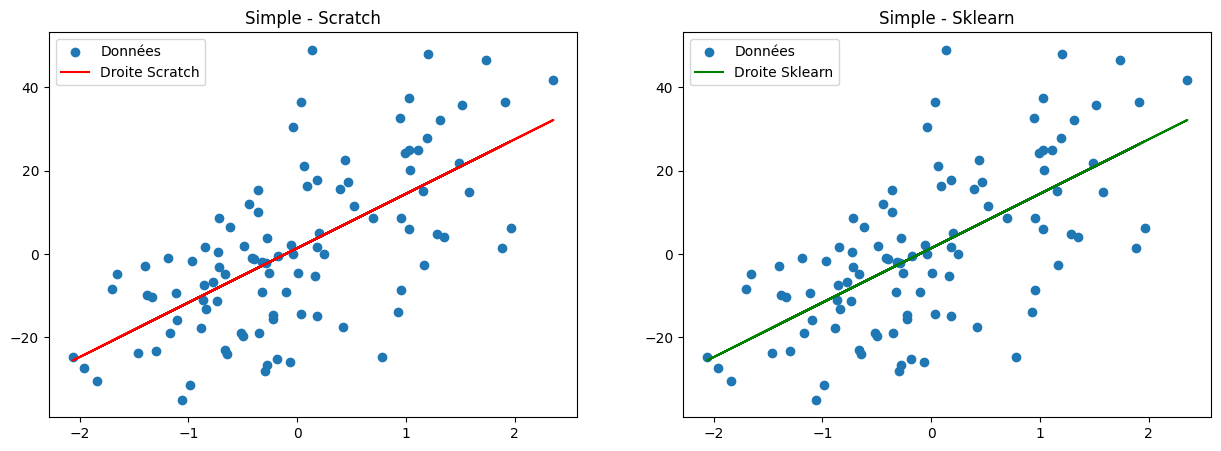

In [57]:
print("Comparaison des paramètres W")
# juste pour comparer les deux solutions (scratch avec GD) et la solution analytique de sklearn
# pour voir si nos solutions sont proches ou non
# W_simple.T juste pour afficher sous forme ligne (plus lisible)
# .intercept_ contient la valeur du biais (w0) et les autres poids de w sont dans .coef_
print("Scratch :", W_simple.T, "| Sklearn :", modele_sklearn_simple.intercept_, modele_sklearn_simple.coef_)

# dans une seule figure on représente la solution scratch et la solution sklearn
plt.figure(figsize=(15, 5))

# 1 ligne, 2 colonnes, position 1
plt.subplot(1, 2, 1)
# scatter pour représenter les points (données réelles)
plt.scatter(X_data_simple, Y_real_simple, label='Données')
# plot pour tracer la courbe (ici la droite prédite en fonction de X)
plt.plot(X_data_simple, predictions_scratch_simple, 'r', label='Droite Scratch')
plt.title('Simple - Scratch')
# afficher la légende
plt.legend()

# 1 ligne, 2 colonnes, position 2
plt.subplot(1, 2, 2)
plt.scatter(X_data_simple, Y_real_simple, label='Données')
plt.plot(X_data_simple, predictions_sklearn_simple, 'g', label='Droite Sklearn')
plt.title('Simple - Sklearn')
plt.legend()

plt.show()


# PARTIE 2: RÉGRESSION LINÉAIRE MULTIPLE

Comme pour la régression simple, on utilise make_regression. La seule différence est (n_features=3). 


## a. DATASET pour la régression linéaire multiple

In [58]:
# '''
# comme expliqué avant, on produit un dataset de 100 points avec 3 features (peu importe lesquelles)
# par exemple, imaginons que ce sont des PC :
# - feature 1 : RAM (4, 16 ...) en Go
# - feature 2 : disque dur (256, 512 ...) en GB
# - feature 3 : CPU (2, 4, 8 ...) cores
# et la target est le prix du PC
# '''
X_data_multi, Y_real_multi = make_regression(n_samples=100, n_features=3, noise=15)

# pour passer de (100,) à (100,1)
Y_real_multi = Y_real_multi.reshape(Y_real_multi.shape[0], 1)

## b. Exécution du code scratch

In [59]:
# '''
# on exécute notre code scratch défini plus haut
# grâce à la formulation linéaire, il peut s’adapter à n’importe quelle dimension de X
# ici X_data_multi est (100,3), mais dans nos fonctions, on ajoute automatiquement la colonne de biais = 1
# donc X devient (100,4) et W est de taille (4,1)
# '''
W_multi = descente_gradient(X_data_multi, Y_real_multi)

# on appelle la fonction qui retourne y_pred de taille (100,1) (X.dot(W))
predictions_scratch_multi = predict_scratch(X_data_multi, W_multi)

itération k= 196


## c. Code sklearn

In [60]:
# même pour sklearn, on crée un objet comme précédemment
modele_sklearn_multi = LinearRegression()

# on appelle la fonction fit de la classe LinearRegression
# elle s’adapte automatiquement à la dimension de X
# et utilise l’espace linéaire pour calculer la solution analytique
modele_sklearn_multi.fit(X_data_multi, Y_real_multi)

# on prédit pour obtenir y_pred
predictions_sklearn_multi = modele_sklearn_multi.predict(X_data_multi)

## d. Comparaison (scratch/sklearn)


En régression multiple, on ne peut plus tracer une droite dans un plan 2D ou 3D à cause des 3 features,
ce qui correspondrait à un espace 4D.  
On va donc seulement comparer les paramètres trouvés.


In [61]:
print("Comparaison des paramètres W")
# comparer les W optimaux de notre scratch et ceux de sklearn
print("Scratch :", W_multi.T, "| Sklearn :", modele_sklearn_multi.intercept_, modele_sklearn_multi.coef_)

# pas de représentation graphique possible ici 
# car on a 4D (Prix (f(x) en fonction de  x= xCPU, xRAM, xDisk )

Comparaison des paramètres W
Scratch : [[ 1.7728233  77.90213857 91.91434299 25.98794449]] | Sklearn : [1.7722935] [[77.90151569 91.91600539 25.98818581]]



# PARTIE 3: RÉGRESSION POLYNOMIALE

Pour ce cas, make_regression n'est pas adapté car il crée des données linéaires.
Nous allons donc créer manuellement un DATASET qui suit une courbe (un polynôme de degré 2),
en y ajoutant un bruit aléatoire afin de le rendre plus réaliste.
L'équation sera de la forme : y = a*x^2 + b*x + c + bruit (noise).

## a. DATASET pour la régression polynomiale

In [62]:
# génération de 100 données aléatoires entre -5 et 1 (1 après la virgule)
X_data_poly = 6 * np.random.rand(100, 1) - 5

# génération de Y réel en fonction de X sous forme polynomiale avec ajout de bruit
Y_real_poly = 0.8 * X_data_poly**2 + X_data_poly + 2 + np.random.randn(100, 1)

## b. Exécution du code scratch

Pour un polynôme de degré 2, on génère les puissances x**1 et x**2


In [64]:
# nos données sont de degré 2, donc il faut préparer X avant de calculer W optimal
degree = 2
# j’utilise la fonction que nous avons définie dans la cellule 1
X_poly_scratch = create_poly_features(X_data_poly, degree)

# une fois que X contient toutes les puissances jusqu’au degré 2, on ajuste W
# RM: au début j’ai testé avec le pas initial 0.1 et j’ai observé que l’algorithme divergeait
# donc j’ai diminué le pas à 0.01 et j’ai augmenté le nombre d’itérations
# pour que le système converge correctement
W_poly = descente_gradient(X_poly_scratch, Y_real_poly, pas=0.01, k_max=3000)

# y_pred après ajustement de W
predictions_scratch_poly = predict_scratch(X_poly_scratch, W_poly)

itération k= 2613


## c. Code sklearn

In [66]:
from sklearn.preprocessing import PolynomialFeatures

# Scikit-learn a un outil dédié pour créer X polynomiale
# simplement, il faut définir le degré et si X contient déjà la colonne de biais ou non
# ici, je mets include_bias=False car notre dataset n’a pas de colonne biais
# c’est ainsi qu’on initialise un objet PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# fit_transform fonctionne comme notre fonction create_poly_features
# il transforme X en matrice contenant toutes les puissances jusqu’au degré choisi
X_poly_sklearn = poly_features.fit_transform(X_data_poly)

# maintenant on peut appliquer la solution analytique de LinearRegression
# initialisation de l’objet
modele_sklearn_poly = LinearRegression()
# calcul de la solution analytique
modele_sklearn_poly.fit(X_poly_sklearn, Y_real_poly)
# prédiction
predictions_sklearn_poly = modele_sklearn_poly.predict(X_poly_sklearn)

## d. Comparaison et graphiques (scratch/sklearn)

Comparaison des paramètres W 
Scratch : [[2.34470335 1.4687565  0.87734416]] | Sklearn : [2.34751738] [[1.47153242 0.87784776]]


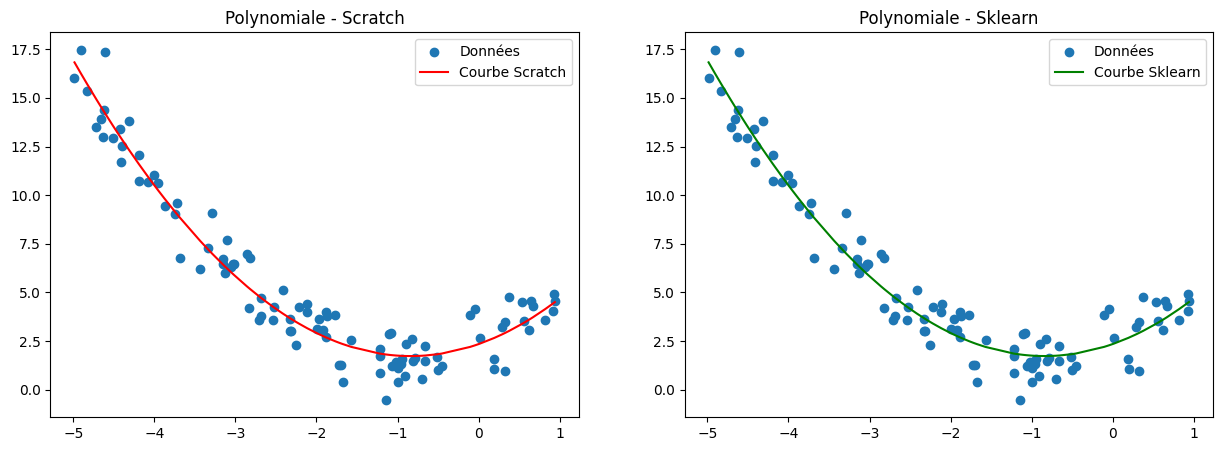

In [69]:
print("Comparaison des paramètres W ")
# comparer les W optimaux de notre scratch et ceux de sklearn
print("Scratch :", W_poly.T, "| Sklearn :", modele_sklearn_poly.intercept_, modele_sklearn_poly.coef_)

plt.figure(figsize=(15, 5))

# '''
# nos données X sont générées aléatoirement, donc elles ne sont pas triées
# si on trace directement la courbe prédite avec plt.plot, la ligne peut sembler incorrecte ou cassée
# np.argsort(X_data_poly) retourne les indices qui trieraient X en ordre croissant
# .flatten() transforme le résultat en vecteur pour pouvoir l’utiliser comme indices
# en utilisant ces indices pour trier X et y_pred, la courbe sera tracée correctement et lisiblement
# '''
idx = np.argsort(X_data_poly, axis=0).flatten()

plt.subplot(1, 2, 1)
plt.scatter(X_data_poly, Y_real_poly, label='Données')
# tracé de la prédiction Scratch, trié pour pour la lisibilité
plt.plot(X_data_poly[idx], predictions_scratch_poly[idx], 'r', label='Courbe Scratch')
plt.title('Polynomiale - Scratch')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_data_poly, Y_real_poly, label='Données')
# tracé de la prédiction Sklearn, trié pour la lisibilité
plt.plot(X_data_poly[idx], predictions_sklearn_poly[idx], 'g', label='Courbe Sklearn')
plt.title('Polynomiale - Sklearn')
plt.legend()

plt.show()